# Sparse Variational Gaussian Process

In [6]:
import numpy as np
import jax.numpy as jnp
import jax.scipy as jsp
import matplotlib as mpl
import matplotlib.pyplot as plt
import jax
import jax.random as jr
from jax import jit, value_and_grad
from scipy.optimize import minimize

jax.config.update("jax_enable_x64", True)
%matplotlib inline

In [7]:
key = jr.key(42)
cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

In [9]:
n = 2500
noise = 0.5

key, subkey = jr.split(key)
X = random.uniform(key=key, minval=-3.0, maxval=3.0, shape=(n,)).reshape(-1, 1)
f = lambda x: jnp.sin(2 * x) + x * jnp.cos(5 * x)
signal = f(X)
y = signal + jr.normal(subkey, shape=signal.shape) * noise

X_test = jnp.linspace(-3.1, 3.1, 500).reshape(-1, 1)
y_test = f(X_test)

In [11]:
X_test.shape

(500, 1)

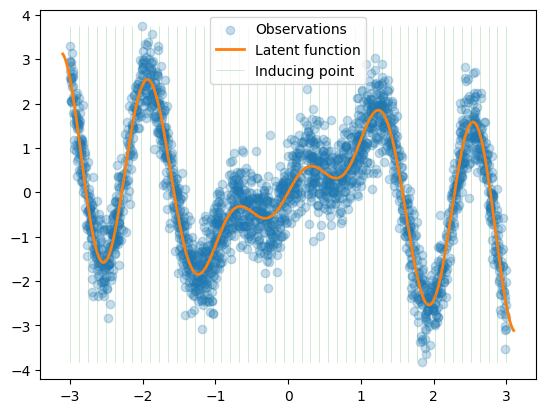

In [13]:
n_inducing = 50
z = jnp.linspace(-3.0, 3.0, n_inducing).reshape(-1, 1)

fig, ax = plt.subplots()
ax.scatter(X, y, alpha=0.25, label="Observations", color=cols[0])
ax.plot(X_test, y_test, label="Latent function", linewidth=2, color=cols[1])
ax.vlines(
    x=z,
    ymin=y.min(),
    ymax=y.max(),
    alpha=0.3,
    linewidth=0.5,
    label="Inducing point",
    color=cols[2],
)
ax.legend(loc="best")
plt.show()

In [21]:
from jax_mc_pilco.model_learning.gp.kernels.stationary import ExpSquared
from jax_mc_pilco.model_learning.gp.sparse_variational_gaussian_process import SparseVariationalGaussianProcess, svgp_fit

In [18]:
params = {
    "kernel":
    {
        "coefficient": jnp.array(0.9,dtype=jnp.float64),
        "log_scale":jnp.array(0.,dtype=jnp.float64)
    },
    "mean":{},
    "likelihood": 
    {
        "log_diag":jnp.array(-0.5,dtype=jnp.float64)
    },
    "inducing_point_locations": z,
}

In [39]:
X.shape, z.shape

((2500, 1), (50, 1))

In [19]:
gp = SparseVariationalGaussianProcess(ExpSquared,X,y,n_inducing,params)

In [22]:
gp_opt = svgp_fit(gp)

In [23]:
predictive_mean, predictive_std = gp_opt.predict(X_test)

In [29]:
predictive_mean.shape, predictive_std.shape

((500,), (500, 500))

In [33]:
predictive_std = jnp.diag(predictive_std)

In [35]:
predictive_mean.shape, predictive_std.shape

((500,), (500,))

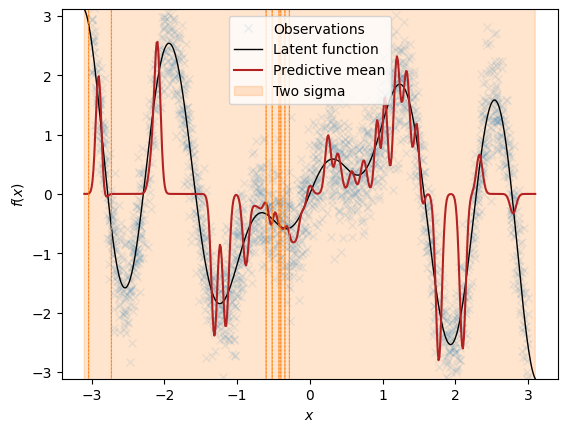

In [41]:
inducing_points = gp_opt.params["inducing_point_locations"]

#samples = latent_dist.sample(key=key, sample_shape=(20,))

fig, ax = plt.subplots()

ax.plot(X, y, "x", label="Observations", color=cols[0], alpha=0.1)
ax.plot(
    X_test,
    y_test,
    label="Latent function",
    color='black',
    linestyle="-",
    linewidth=1,
)
ax.plot(X_test, predictive_mean, label="Predictive mean", color='firebrick')

ax.fill_between(
    X_test.squeeze(),
    predictive_mean - 2 * predictive_std,
    predictive_mean + 2 * predictive_std,
    alpha=0.2,
    color=cols[1],
    label="Two sigma",
)
ax.plot(
    X_test,
    predictive_mean - 2 * predictive_std,
    color=cols[1],
    linestyle="--",
    linewidth=0.5,
)
ax.plot(
    X_test,
    predictive_mean + 2 * predictive_std,
    color=cols[1],
    linestyle="--",
    linewidth=0.5,
)


# ax.vlines(
#     x=inducing_points,
#     ymin=y_test.min(),
#     ymax=y_test.max(),
#     alpha=0.3,
#     linewidth=0.5,
#     label="Inducing point",
#     color=cols[2],
# )
ax.set_ylim(y_test.min(),y_test.max())
ax.legend()
ax.set(xlabel=r"$x$", ylabel=r"$f(x)$")
plt.show()

In [38]:
inducing_points

Array([[-4.62422076e+00],
       [-1.06086789e+02],
       [ 1.24644395e+02],
       [-3.42795528e+00],
       [-2.88453043e+00],
       [-2.88448254e+00],
       [-3.56428997e-01],
       [-6.56168187e+00],
       [-2.58521070e-01],
       [-4.76626891e-01],
       [-4.21640920e+00],
       [ 2.81278670e-01],
       [-2.09635600e+00],
       [-2.17780919e+00],
       [-4.41373220e-01],
       [-1.31186551e+00],
       [-1.15140783e+00],
       [-6.67325132e-01],
       [-8.78439823e-01],
       [-7.54149802e-01],
       [-5.04899080e-01],
       [-3.80492450e-01],
       [-4.37262190e-01],
       [-1.78858526e-01],
       [-2.80277637e-02],
       [-5.58328886e-02],
       [ 2.59277819e-01],
       [ 4.23978612e-01],
       [ 3.76214121e-01],
       [ 5.78315734e-01],
       [ 6.76839857e-01],
       [ 7.43498974e-01],
       [ 1.00101435e+00],
       [ 9.84351320e-01],
       [ 9.59365022e-01],
       [ 1.19523618e+00],
       [ 1.48851705e+00],
       [ 1.51455289e+00],
       [ 1.5